In [7]:
import numpy as np
import scipy.constants
import scipy.sparse
from scipy.stats import norm
import matplotlib.pyplot as plt
import xarray as xr
import math
import geopandas as gpd
import pandas as pd
import os
import netCDF4 as nc

In [8]:
def get_u(ds, year):

    '''Calculates U, the fraction of high angle wave contribution to Q_s over the total wave contribution to Q_s over one year.
    High-angle threshold is defined by the absolute angle between wave crests and the shoreline being greater than pi/4.'''
    
    ds_year = ds.sel(time=str(year))
    high_mask = (ds_year['angle_diff'] > (np.pi/4)) | (ds_year['angle_diff'] < -(np.pi/4))
    low_mask  = (ds_year['angle_diff'] <= (np.pi/4)) & (ds_year['angle_diff'] >= -(np.pi/4))
    qs_high = np.abs(ds_year['qs'].where(high_mask)).sum(dim='time')
    qs_low  = np.abs(ds_year['qs'].where(low_mask)).sum(dim='time')
    total = qs_low + qs_high
    u = (qs_high / total).fillna(0)
    return u

In [13]:
def get_a(ds, year):
    
    '''Calculates A, the fraction of high rightward wave contribution to Q_s over the total wave contribution to Q_s over one year.'''
    
    ds_year = ds.sel(time=str(year))
    left_mask = (ds_year['angle_diff'] < 0)
    right_mask = (ds_year['angle_diff'] >= 0)
    qs_left = np.abs(ds_year['qs'].where(left_mask)).sum(dim='time')
    qs_right  = np.abs(ds_year['qs'].where(right_mask)).sum(dim='time')
    total = qs_left + qs_right
    a = (qs_left / total).fillna(0)
    return a  

In [10]:
ds = xr.open_dataset('ncqs_hourly_pertransect.nc')

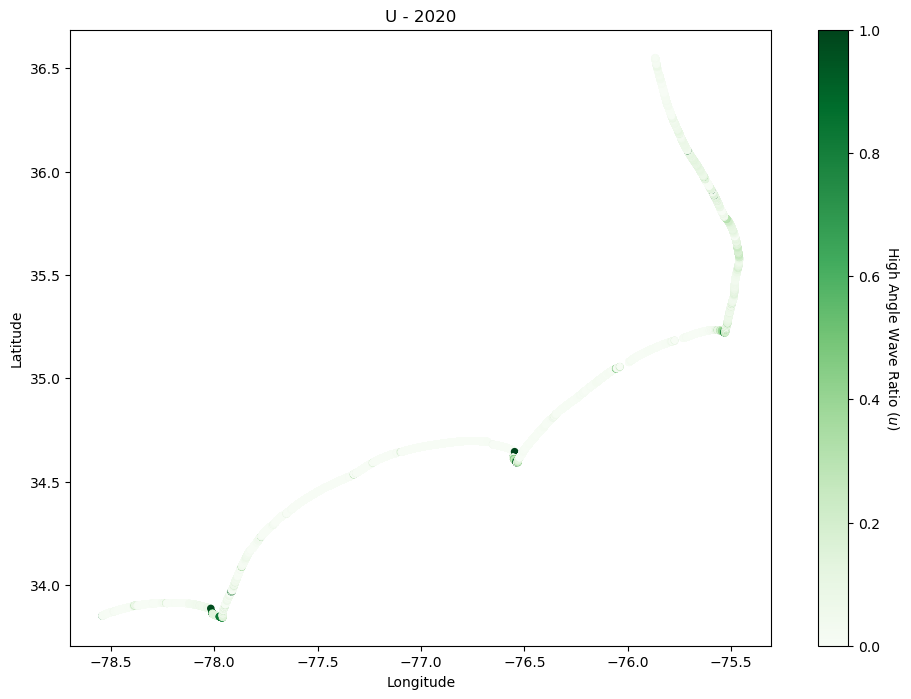

In [11]:
# plot U for a specific year

year = 2020
u = get_u(ds,year)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    ds.lon, 
    ds.lat, 
    c=u, 
    cmap='Greens', 
    s=20, 
    vmin=0, vmax=1
)

cbar = plt.colorbar(scatter)
cbar.set_label('High Angle Wave Ratio ($u$)', rotation=270, labelpad=15)

plt.title(f'U - {year}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.gca().set_aspect('equal')

plt.show()

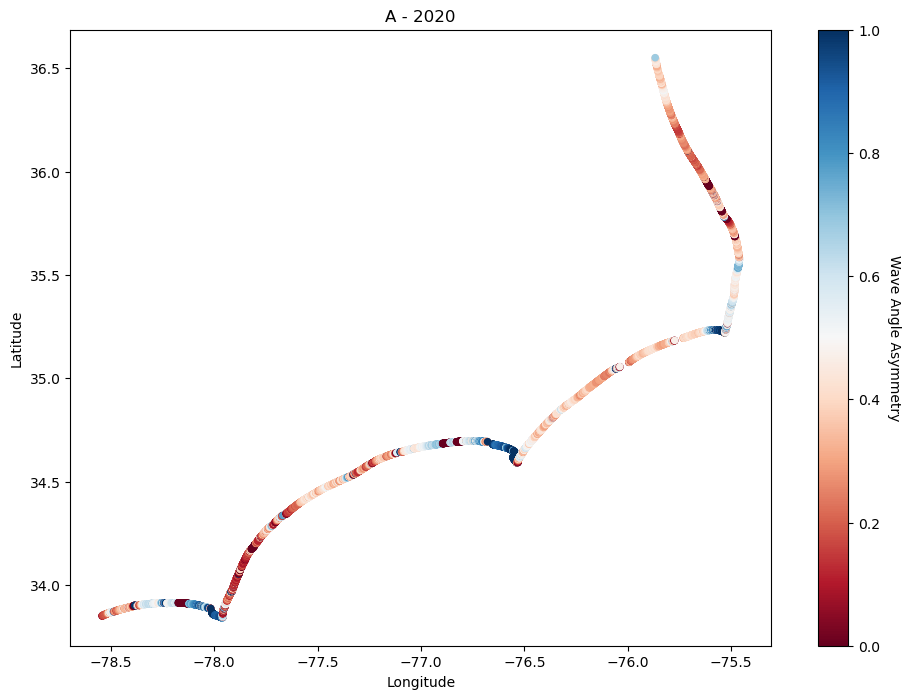

In [14]:
# plot A for a specific year

year = 2020
a = get_a(ds,year)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    ds.lon, 
    ds.lat, 
    c=a, 
    cmap='RdBu', 
    s=20, 
    vmin=0, vmax=1
)

cbar = plt.colorbar(scatter)
cbar.set_label('Wave Angle Asymmetry', rotation=270, labelpad=15)

plt.title(f'A - {year}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.gca().set_aspect('equal')

plt.show()